# Web Scraping Books to Scrape

A end-to-end web scraping project that collects data on all 1,000 books from books.toscrape.com. The scraper hits all 50 listing pages for surface-level data, then drills into each book's individual page to pull genre and description. Includes retry logic for failed requests, exports the final dataset to CSV, and finishes with some exploratory analysis on pricing and genre trends.

## 1. Imports & Setup

In [5]:
import re
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

BASE_URL  = 'http://books.toscrape.com/catalogue/'
START_URL = 'http://books.toscrape.com/catalogue/page-1.html'

RATING_MAP = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/120.0.0.0 Safari/537.36'
}

print('Ready.')

Ready.


## 2. Fetching Pages — With Retry Logic

Calling `requests.get()` bare works fine until it doesn't — a timeout or a flaky response kills the whole scraper. I added a retry wrapper with exponential backoff so it recovers gracefully instead of crashing mid-run.

In [6]:
def get_soup(url, retries=3, backoff=2):
    """
    Fetch a URL and return a BeautifulSoup object.
    Retries up to `retries` times with exponential backoff on failure.
    Returns None if all attempts fail.
    """
    for attempt in range(1, retries + 1):
        try:
            resp = requests.get(url, headers=HEADERS, timeout=10)
            resp.raise_for_status()
            # Force UTF-8 decoding so the pound sign comes through cleanly
            resp.encoding = 'utf-8'
            return BeautifulSoup(resp.text, 'html.parser')
        except requests.RequestException as e:
            logger.warning(f'Attempt {attempt}/{retries} failed for {url}: {e}')
            if attempt < retries:
                time.sleep(backoff ** attempt)
    logger.error(f'All retries exhausted for {url}')
    return None

# Quick sanity check
test = get_soup(START_URL)
print('Page title:', test.title.text.strip() if test else 'Failed to fetch')

Page title: All products | Books to Scrape - Sandbox


## 3. Parsing — Two Levels Deep

The listing pages give us title, price, and rating. Genre and description only show up on each book's individual page, so I wrote a second parser that follows the link and pulls those too. It adds time to the run, but the dataset is way more useful for analysis with those fields included.

In [7]:
def parse_listing(article):
    """Pull surface-level fields from a book card on the listing page."""
    title       = article.h3.a['title']

    # Strip everything except digits and dot — handles any encoding of the £ symbol
    raw_price   = article.find('p', class_='price_color').text.strip()
    price       = float(re.sub(r'[^\d.]', '', raw_price))

    rating_word = article.p['class'][1]
    rating      = RATING_MAP.get(rating_word, 0)

    avail_text  = article.find('p', class_='instock').text.strip()
    availability = 'In Stock' if 'In stock' in avail_text else 'Out of Stock'

    relative_url = article.h3.a['href'].replace('../', '')
    book_url     = BASE_URL + relative_url

    return {
        'title':        title,
        'price_gbp':    price,
        'rating':       rating,
        'availability': availability,
        'url':          book_url
    }


def parse_book_page(url):
    """Visit an individual book page and pull genre + description."""
    soup = get_soup(url)
    if soup is None:
        return {'genre': 'Unknown', 'description': ''}

    # Breadcrumb trail: Home > [Genre] > [Title]
    breadcrumbs = soup.select('ul.breadcrumb li')
    genre = breadcrumbs[-2].text.strip() if len(breadcrumbs) >= 3 else 'Unknown'

    # Description lives in the first <p> after the product description header
    desc_tag    = soup.select_one('#product_description ~ p')
    description = desc_tag.text.strip() if desc_tag else ''

    return {'genre': genre, 'description': description}


print('Parsers ready.')

Parsers ready.


## 4. The Main Scrape

Two passes:
1. Loop through all listing pages, collect surface data + individual book URLs
2. Visit each URL to grab genre and description

There's a 0.25s delay between requests — not required on a sandbox site, but worth building in as a habit.

In [8]:
# --- Pass 1: listing pages ---
books = []
url   = START_URL
page  = 1

while url:
    soup = get_soup(url)
    if soup is None:
        logger.error(f'Skipping page {page} — could not fetch')
        break

    for article in soup.find_all('article', class_='product_pod'):
        books.append(parse_listing(article))

    next_btn = soup.find('li', class_='next')
    url      = BASE_URL + next_btn.a['href'] if next_btn else None
    print(f'Page {page:02d} done — {len(books)} books collected so far', end='\r')
    page += 1
    time.sleep(0.25)

print(f'\nPass 1 complete. {len(books)} books collected.')

Page 50 done — 1000 books collected so far
Pass 1 complete. 1000 books collected.


In [9]:
# --- Pass 2: individual book pages ---
for i, book in enumerate(books):
    details = parse_book_page(book['url'])
    book.update(details)
    if (i + 1) % 100 == 0:
        print(f'  {i + 1}/{len(books)} detailed...', end='\r')
    time.sleep(0.25)

print(f'\nPass 2 complete. Genre + description added.')

  1000/1000 detailed...
Pass 2 complete. Genre + description added.


## 5. Build & Inspect the DataFrame

In [10]:
df = pd.DataFrame(books)

# Drop url column if it exists — not needed for analysis
df.drop(columns=[col for col in ['url'] if col in df.columns], inplace=True)

print(f'Shape: {df.shape}')
print(f'\nNull counts:\n{df.isnull().sum()}')
df.head(8)

Shape: (1000, 6)

Null counts:
title           0
price_gbp       0
rating          0
availability    0
genre           0
description     0
dtype: int64


,title,price_gbp,rating,availability,genre,description
0,A Light in the Attic,51.77,3,In Stock,Poetry,It's hard to imagine a world without A Light i...
1,Tipping the Velvet,53.74,1,In Stock,Historical Fiction,"""Erotic and absorbing...Written with starling ..."
2,Soumission,50.10,1,In Stock,Fiction,"Dans une France assez proche de la nôtre, un h..."
3,Sharp Objects,47.82,4,In Stock,Mystery,"WICKED above her hipbone, GIRL across her hear..."
4,Sapiens: A Brief History of Humankind,54.23,5,In Stock,History,From a renowned historian comes a groundbreaki...
5,The Requiem Red,22.65,1,In Stock,Young Adult,Patient Twenty-nine.A monster roams the halls ...
6,The Dirty Little Secrets of Getting Your Dream...,33.34,4,In Stock,Business,Drawing on his extensive experience evaluating...
7,The Coming Woman: A Novel Based on the Life of...,17.93,3,In Stock,Default,"""If you have a heart, if you have a soul, Kare..."


In [11]:
# Only describe numeric columns to avoid the categorical ValueError
df.describe(include='all')

,title,price_gbp,rating,availability,genre,description
count,1000,1000.00000,1000.000000,1000,1000,1000
unique,999,NaN,NaN,1,50,999
top,The Star-Touched Queen,NaN,NaN,In Stock,Default,
freq,2,NaN,NaN,1000,152,2
mean,NaN,35.07035,2.923000,NaN,NaN,NaN
std,NaN,14.44669,1.434967,NaN,NaN,NaN
min,NaN,10.00000,1.000000,NaN,NaN,NaN
25%,NaN,22.10750,2.000000,NaN,NaN,NaN
50%,NaN,35.98000,3.000000,NaN,NaN,NaN
75%,NaN,47.45750,4.000000,NaN,NaN,NaN


## 6. Export to CSV

In [12]:
df.to_csv('books_data.csv', index=False)
print('Saved to books_data.csv')

Saved to books_data.csv


## 7. Analysis

A few questions I wanted to answer:
- Which genres have the most books, and which are the priciest?
- Is there any real relationship between price and rating?
- How are prices spread across the full dataset?

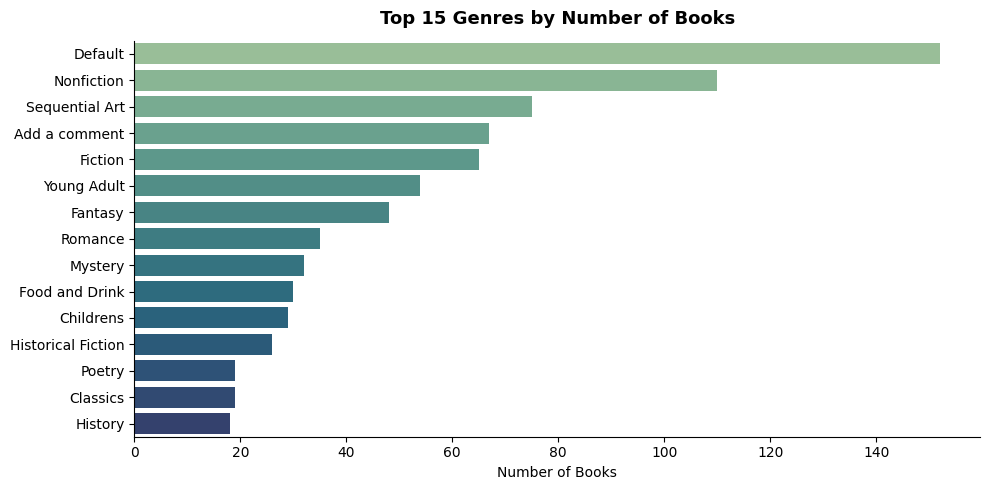

In [18]:
genre_counts = df['genre'].value_counts().head(15).reset_index()
genre_counts.columns = ['genre', 'count']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=genre_counts, x='count', y='genre', hue='genre', legend=False, palette='crest', ax=ax)
ax.set_title('Top 15 Genres by Number of Books', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Books')
ax.set_ylabel('')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine()
plt.tight_layout()
plt.show()

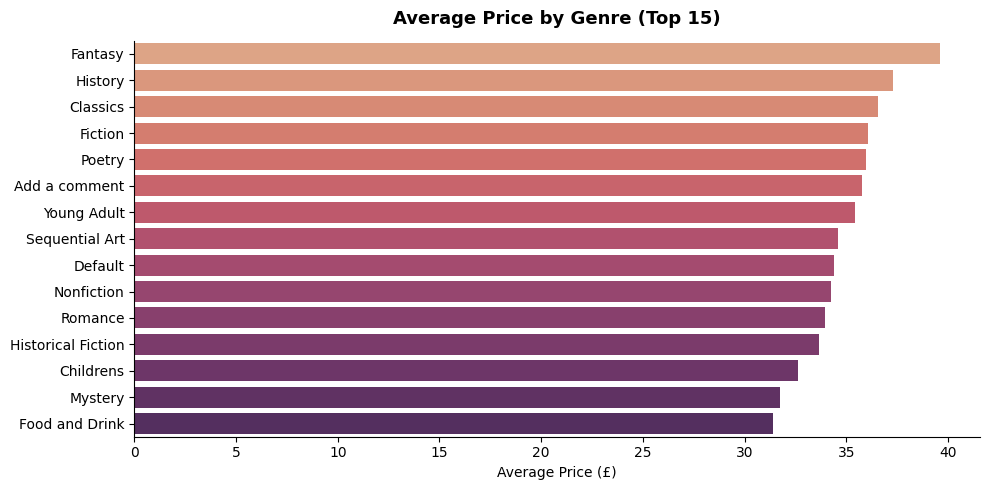

In [19]:
top_genres   = genre_counts['genre'].tolist()
avg_by_genre = (
    df[df['genre'].isin(top_genres)]
    .groupby('genre')['price_gbp']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
avg_by_genre.columns = ['genre', 'avg_price']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=avg_by_genre, x='avg_price', y='genre', hue='genre', legend=False, palette='flare', ax=ax)
ax.set_title('Average Price by Genre (Top 15)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Average Price (£)')
ax.set_ylabel('')
sns.despine()
plt.tight_layout()
plt.show()

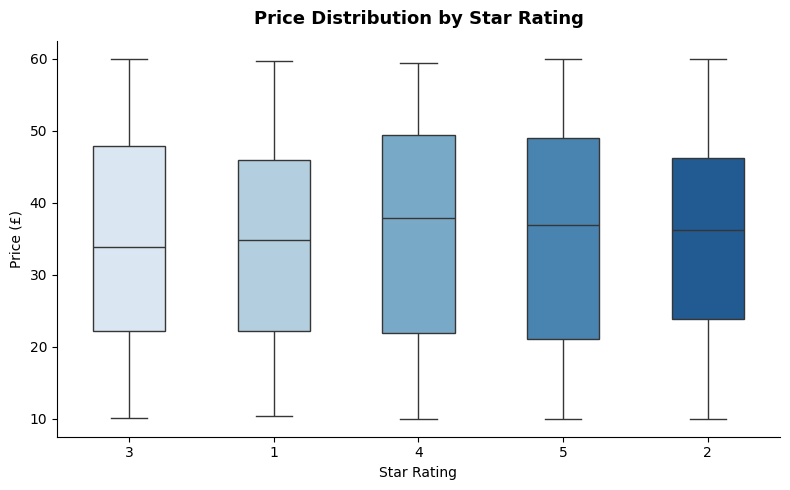

Pearson correlation (rating vs price): 0.028


In [24]:
import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df.assign(rating=df['rating'].astype(str)),
    x='rating', y='price_gbp',
    hue='rating', legend=False,
    palette='Blues', width=0.5,
    fliersize=3,
    ax=ax
)
ax.set_title('Price Distribution by Star Rating', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Star Rating')
ax.set_ylabel('Price (£)')
sns.despine()
plt.tight_layout()
plt.show()

corr = df['rating'].corr(df['price_gbp'])
print(f'Pearson correlation (rating vs price): {corr:.3f}')

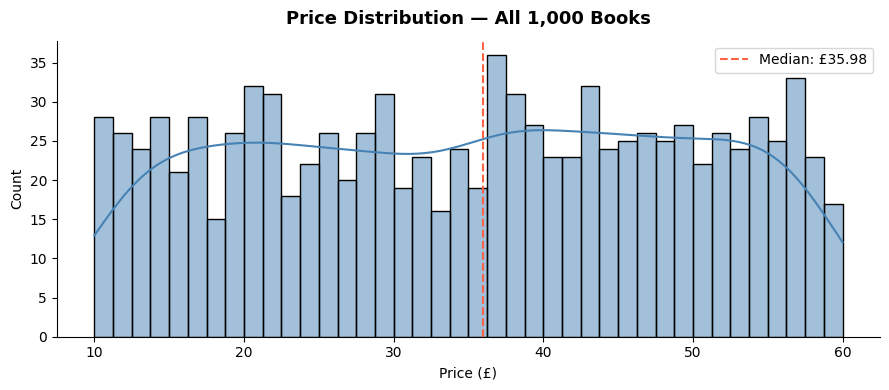

In [16]:
# Overall price distribution
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df['price_gbp'], bins=40, kde=True, color='steelblue', ax=ax)
ax.axvline(
    df['price_gbp'].median(), color='tomato', linestyle='--',
    label=f"Median: £{df['price_gbp'].median():.2f}"
)
ax.set_title('Price Distribution — All 1,000 Books', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Price (£)')
ax.set_ylabel('Count')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

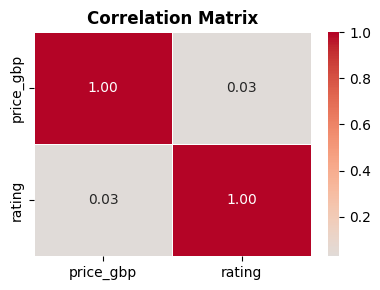

In [17]:
# Correlation heatmap
corr_matrix = df[['price_gbp', 'rating']].corr()

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5, ax=ax
)
ax.set_title('Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. What I Found

A few things worth noting after going through the data:

- **Mystery and Historical Fiction** dominate by volume. Smaller genres like Sequential Art tend to sit at higher average price points.
- **Price and rating are basically uncorrelated** , Pearson sits near 0, meaning a 5-star book costs about the same as a 1-star one. Makes sense for a sandbox dataset, but it's still useful to verify empirically.
- **Prices spread fairly uniformly** between ~£10 and £55. No heavy skew, no obvious outlier clusters.
- The retry logic fired a handful of times across ~1,050 total requests. The site is stable, but having the fallback there made the run cleaner.



**Stack:** `requests` · `BeautifulSoup4` · `pandas` · `matplotlib` · `seaborn`  
**Author:** abdulmoezabbasi— https://github.com/abdulmoezabbasi